In [1]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_last_second_line_metrics(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    # The second last line
    line = lines[-2]
    
    # Regex to capture val_loss, train_time, step_avg
    val_loss_pattern = r"val_loss:\s*([\d\.e+-]+)"
    train_time_pattern = r"train_time:\s*([\d\.e+-]+)"
    step_avg_pattern = r"step_avg:\s*([\d\.e+-]+)"
    
    val_loss_match = re.search(val_loss_pattern, line)
    train_time_match = re.search(train_time_pattern, line)
    step_avg_match = re.search(step_avg_pattern, line)
    
    val_loss = float(val_loss_match.group(1)) if val_loss_match else None
    train_time = float(train_time_match.group(1)) if train_time_match else None
    step_avg = float(step_avg_match.group(1)) if step_avg_match else None
    
    return val_loss, train_time, step_avg

def get_stats(path):
    last_second_metrics = []
    parent_directory = path
    for file_name in os.listdir(parent_directory):
        file_path = os.path.join(parent_directory, file_name)
        metrics = extract_last_second_line_metrics(file_path)
        if all(m is not None for m in metrics):  # Ensure valid metrics
            last_second_metrics.append(metrics)
    # Convert to a DataFrame for easier calculation
    df = pd.DataFrame(last_second_metrics, columns=["val_loss", "train_time", "step_avg"])
    df['train_time'] = df['train_time']/1000/60
    # Calculate mean and variance for each metric
    final_metrics = {
        "val_loss": {"mean": df["val_loss"].mean(), "variance": df["val_loss"].var()},
        "train_time": {"mean": df["train_time"].mean(), "variance": df["train_time"].var()},
        "step_avg": {"mean": df["step_avg"].mean(), "variance": df["step_avg"].var()},
    }
    return df, final_metrics

# Define a function to plot a grouped boxplot
def plot_grouped_boxplot(data, value_col, ylabel, title):
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=data, hue="source", y=value_col, inner="point", palette="muted")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


In [3]:
bidirectional_df, bidirectional_metrics = get_stats('./bidirectional')
bidirectional_df['source'] = 'bidirectional_records'
MFUTweaks_df, MFUTweaks_metrics = get_stats('./MFUTweaks')
MFUTweaks_df['source'] = 'MFUTweaks_record'
combined_df = pd.concat([bidirectional_df, MFUTweaks_df], ignore_index=True)

In [4]:
bidirectional_metrics

{'val_loss': {'mean': np.float64(3.2787600000000006),
  'variance': np.float64(1.3639999999999303e-06)},
 'train_time': {'mean': np.float64(12.291031111111112),
  'variance': np.float64(9.211467724867425e-05)},
 'step_avg': {'mean': np.float64(501.67400000000004),
  'variance': np.float64(0.15203999999999812)}}

In [5]:
MFUTweaks_metrics

{'val_loss': {'mean': np.float64(3.278893333333333),
  'variance': np.float64(2.0520952380952693e-06)},
 'train_time': {'mean': np.float64(12.33802111111111),
  'variance': np.float64(0.00010127755820106062)},
 'step_avg': {'mean': np.float64(503.59333333333336),
  'variance': np.float64(0.16842380952381178)}}

In [6]:
combined_df

,val_loss,train_time,step_avg,source
0,3.2803,12.304900,502.24,bidirectional_records
1,3.2784,12.301300,502.09,bidirectional_records
2,3.2768,12.299583,502.02,bidirectional_records
3,3.2798,12.294933,501.83,bidirectional_records
4,3.2779,12.288450,501.57,bidirectional_records
5,3.2786,12.288033,501.55,bidirectional_records
6,3.2797,12.295317,501.85,bidirectional_records
7,3.2773,12.298000,501.96,bidirectional_records
8,3.2798,12.292233,501.72,bidirectional_records
9,3.2805,12.274400,501.00,bidirectional_records


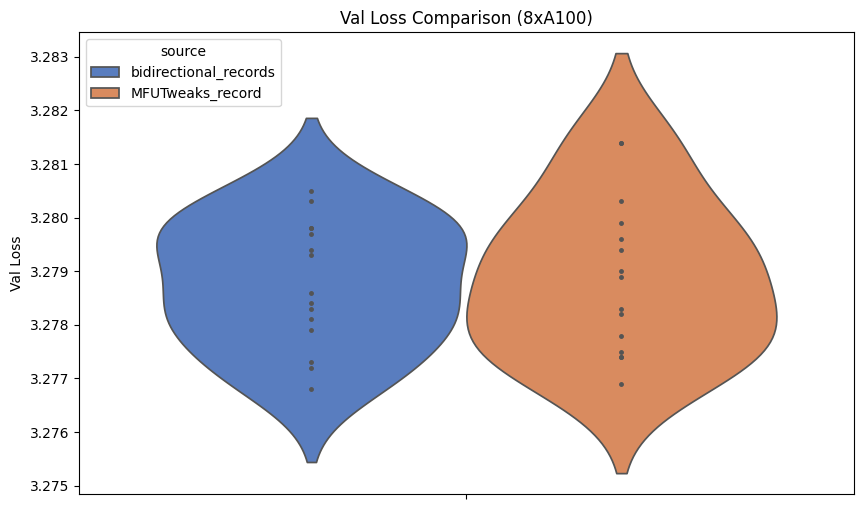

In [7]:
plot_grouped_boxplot(combined_df, "val_loss", "Val Loss", "Val Loss Comparison (8xA100)")

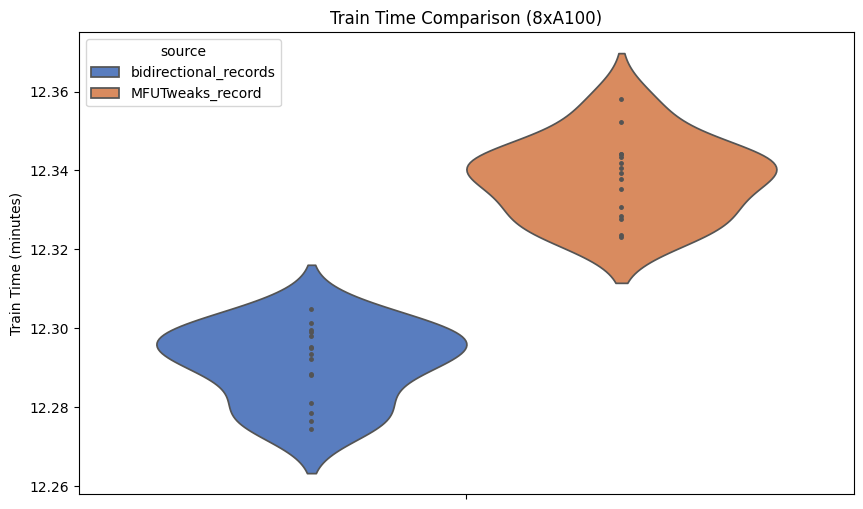

In [8]:
plot_grouped_boxplot(combined_df, "train_time", "Train Time (minutes)", "Train Time Comparison (8xA100)")